In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn as nn
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,Dataset
from torchvision.transforms import ToTensor
import random
import os
from pathlib import Path
import requests
import zipfile
import pathlib
from PIL import Image
from typing import Tuple,Dict,List


In [2]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"Directory {image_path} exists")
else:
    print(f"Directory {image_path} does not exist")
    print("Downloading Now")
    print(f"{image_path} is created")
    image_path.mkdir(parents=True,exist_ok=True)
    
    with open (data_path / "pizza_steak_sushi.zip","wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)
        
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip",'r') as zip_ref:
        zip_ref.extractall(data_path)

Directory data/pizza_steak_sushi exists


In [3]:
def walk_through(dir_path):
    for dirpath,dirnames,filenames in os.walk(dir_path):
        print(f"Current directory: {dirpath} and {len(filenames)} images")

In [4]:
walk_through(image_path)

Current directory: data/pizza_steak_sushi and 0 images
Current directory: data/pizza_steak_sushi/test and 0 images
Current directory: data/pizza_steak_sushi/test/steak and 19 images
Current directory: data/pizza_steak_sushi/test/sushi and 31 images
Current directory: data/pizza_steak_sushi/test/pizza and 25 images
Current directory: data/pizza_steak_sushi/train and 0 images
Current directory: data/pizza_steak_sushi/train/steak and 75 images
Current directory: data/pizza_steak_sushi/train/sushi and 72 images
Current directory: data/pizza_steak_sushi/train/pizza and 78 images


In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [6]:
random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list

[PosixPath('data/pizza_steak_sushi/test/steak/296375.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/894825.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1016217.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/3424937.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/354513.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2117351.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/100274.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2144308.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/966174.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1882831.jpg'),
 PosixPath('data/pizza_steak_sushi

Random Image Path : data/pizza_steak_sushi/test/steak/100274.jpg
Image Class : steak
Image Size : (512, 384)


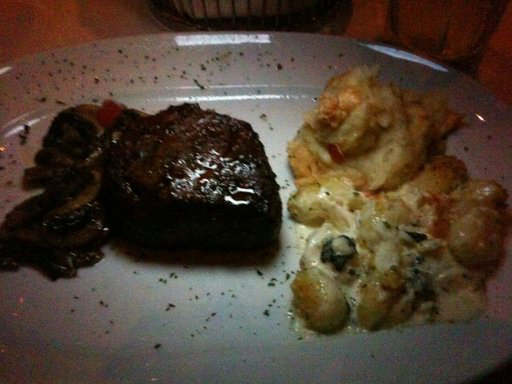

In [8]:
random_image_path = random.choice(image_path_list)
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)
print(f"Random Image Path : {random_image_path}")
print(f"Image Class : {image_class}")
print(f"Image Size : {img.size}")
img


(-0.5, 511.5, 383.5, -0.5)

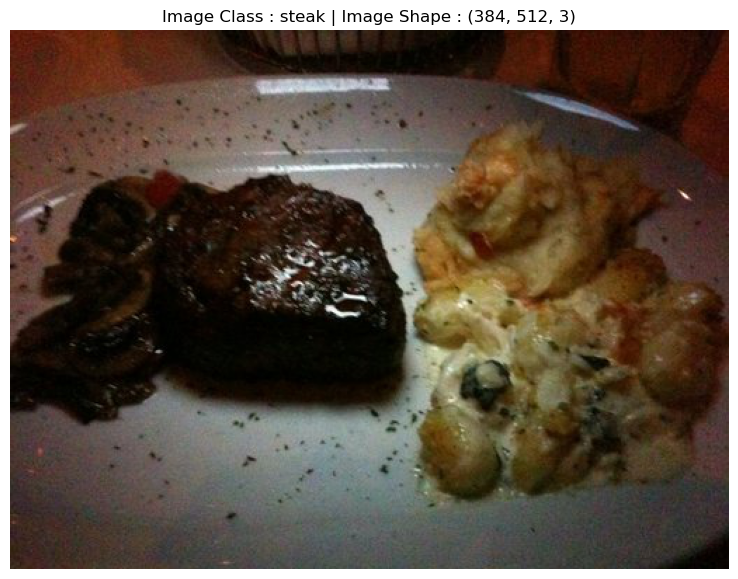

In [9]:
img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image Class : {image_class} | Image Shape : {img_as_array.shape}")
plt.axis(False)

In [10]:
img_as_array

array([[[94, 31, 16],
        [96, 33, 18],
        [97, 34, 19],
        ...,
        [49,  9,  0],
        [54, 14,  2],
        [59, 17,  5]],

       [[94, 31, 16],
        [95, 32, 17],
        [92, 29, 14],
        ...,
        [53, 13,  3],
        [61, 19,  7],
        [64, 22,  8]],

       [[94, 28, 14],
        [94, 31, 16],
        [93, 30, 15],
        ...,
        [57, 17,  5],
        [64, 22, 10],
        [66, 24, 10]],

       ...,

       [[53, 39, 26],
        [57, 43, 30],
        [64, 48, 35],
        ...,
        [ 8,  3,  0],
        [ 8,  3,  0],
        [ 9,  4,  1]],

       [[57, 43, 30],
        [66, 52, 39],
        [65, 51, 38],
        ...,
        [ 6,  1,  0],
        [ 7,  2,  0],
        [ 7,  2,  0]],

       [[56, 42, 29],
        [64, 50, 37],
        [57, 43, 30],
        ...,
        [ 9,  4,  1],
        [ 9,  4,  1],
        [10,  5,  2]]], dtype=uint8)

In [24]:
img_as_array.dtype,img_as_array.shape

(dtype('uint8'), (384, 512, 3))

In [21]:
data_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [22]:
data_transform(img).dtype

torch.float32

In [23]:
data_transform(img)

tensor([[[0.1922, 0.1216, 0.1216,  ..., 0.3686, 0.3608, 0.3647],
         [0.2275, 0.1333, 0.1294,  ..., 0.3490, 0.3569, 0.3569],
         [0.2627, 0.1529, 0.1294,  ..., 0.3216, 0.3569, 0.3490],
         ...,
         [0.0431, 0.0784, 0.1176,  ..., 0.2431, 0.2314, 0.2196],
         [0.0353, 0.0392, 0.0510,  ..., 0.2510, 0.2431, 0.2196],
         [0.0353, 0.0275, 0.0275,  ..., 0.2627, 0.2549, 0.2314]],

        [[0.0549, 0.0392, 0.0431,  ..., 0.1137, 0.1137, 0.1137],
         [0.0667, 0.0431, 0.0431,  ..., 0.1176, 0.1137, 0.1098],
         [0.0745, 0.0510, 0.0392,  ..., 0.1294, 0.1176, 0.1216],
         ...,
         [0.0196, 0.0471, 0.1098,  ..., 0.1569, 0.1529, 0.1490],
         [0.0196, 0.0157, 0.0353,  ..., 0.1529, 0.1490, 0.1412],
         [0.0196, 0.0196, 0.0196,  ..., 0.1529, 0.1529, 0.1569]],

        [[0.0235, 0.0275, 0.0196,  ..., 0.0471, 0.0471, 0.0510],
         [0.0314, 0.0235, 0.0196,  ..., 0.0549, 0.0549, 0.0510],
         [0.0275, 0.0235, 0.0196,  ..., 0.0667, 0.0667, 0.

In [25]:
data_transform(img).shape


torch.Size([3, 64, 64])

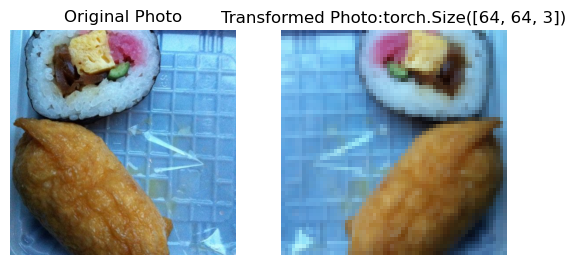

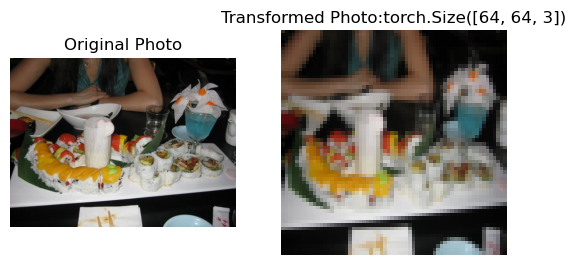

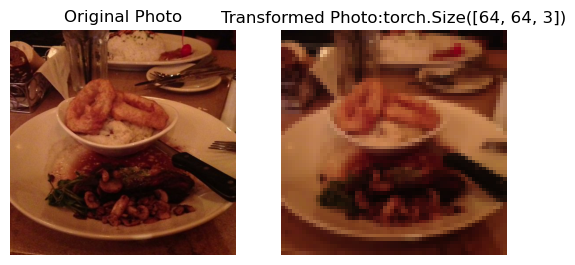

In [28]:
def plot_transformed_image(image_paths:list,transform,n=3,seed=None):
    if seed:
        random.seed(seed)
    random_image_path = random.sample(image_paths,k=n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            fig,ax = plt.subplots(1,2)
            ax[0].imshow(f)
            ax[0].set_title('Original Photo')
            ax[0].axis('off')
            
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f'Transformed Photo:{transformed_image.shape}')
            ax[1].axis('off')
            
plot_transformed_image(image_paths=image_path_list,transform=data_transform,n=3)

In [29]:
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,
                                  target_transform=None)

test_data = datasets.ImageFolder(root=test_dir,transform=data_transform)

In [30]:
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [32]:
classnames=train_data.classes
classnames

['pizza', 'steak', 'sushi']

In [33]:
test_data.classes

['pizza', 'steak', 'sushi']

In [34]:
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [37]:
img,label = train_data[1][0],train_data[0][1]
img.shape,img.dtype

(torch.Size([3, 64, 64]), torch.float32)

Text(0.5, 1.0, 'pizza')

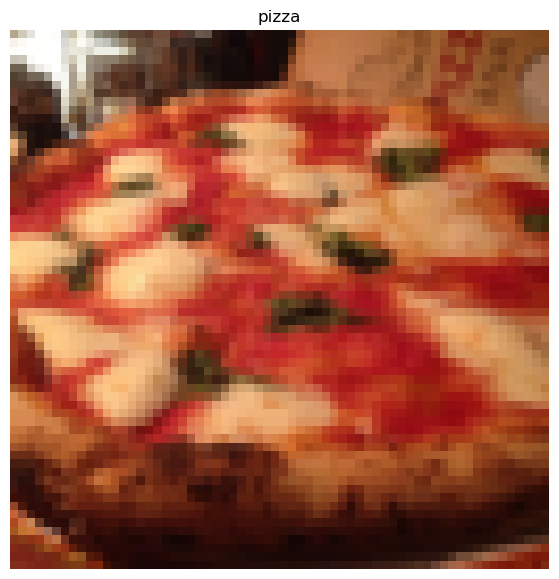

In [38]:
img_permute = img.permute(1,2,0)
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(classnames[label])

Create the Data loader so we can start training and developing a model

In [39]:
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=1,
                              num_workers=1,
                              shuffle=True)
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=1,
                             num_workers=1,
                             shuffle=False)

In [40]:
len(train_dataloader),len(test_dataloader)

(225, 75)

In [42]:
img,label = next(iter(train_dataloader))
img.shape,label.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1]))

In [43]:
target_directory = train_dir
print(f"Target Dir :{target_directory}")

class_names_found = sorted(entry.name for entry in list(os.scandir(target_directory)))
print(f"Class Names Found: {class_names_found}")

Target Dir :data/pizza_steak_sushi/train
Class Names Found: ['pizza', 'steak', 'sushi']


In [44]:
def class_finder(directory:str) -> Tuple[list[str], Dict[str,int]]:
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"No Classes in {target_directory}")
    
    class_to_idx = {class_name:i for i,class_name in enumerate(classes)}
    return classes,class_to_idx

In [45]:
class_finder(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

Creating a Custom Dataset:
1) Subclasss torch.utils.data.Dataset
2) init our subclass with a target directory (The directory from which we woulf like our data) if we want to transform it.
3) Paths - paths of images
   Transform - the transform we would use
   classes - a list of target classes
   class_to_idx - a dictionary of target classes
4) create a function to load images
5) __len__ so that len(dataset) returns the size of the dataset
6) __getitems__ overwrite

In [48]:
class ImageFolderCustom(Dataset):
    def __init__(self,target_dir:str,transform=None):
        self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))
        self.transform = transform
        self.classes,self.class_to_idx = class_finder(target_dir)
        
    def load_image(self,index:int) -> Image.Image:
        return Image.open(self.paths[index])
    
    def __len__(self) -> int:
        return len(self.paths)
    
    def __getitem__(self, index:int) -> Tuple[torch.Tensor,int]:
        img = self.load_image()
        class_names = self.paths[index].parent.name
        class_idx = self.class_to_idx[class_names]
        
        if self.transform:
            return self.transform(img),class_idx
        else:
            img,class_idx
            


In [49]:
train_transfroms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])